<a href="https://colab.research.google.com/github/Syauqimaul/2025_Pengolahan-Citra_TI-2A/blob/main/Jobsheet%2004%3A%20Segmentasi%20Gambar.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Praktikum 1. Segmentasi Menggunakan Thresholding Global dan Otsu

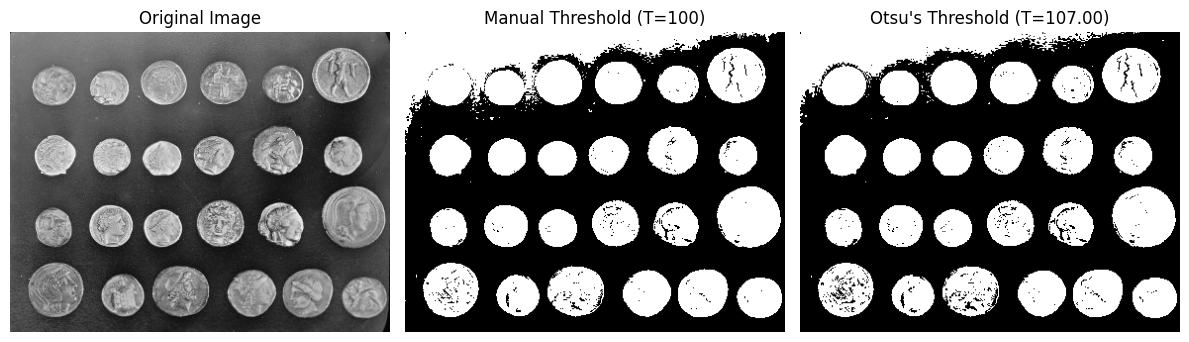

Nilai threshold Otsu yang diperoleh: 107.00


In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters

# 1. Memuat citra contoh (coins)
image_coins = data.coins()  # Citra sudah dalam format grayscale

# 2. Thresholding Global (manual)
thresh_manual = 100
binary_manual = image_coins > thresh_manual

# 3. Thresholding Otsu (otomatis)
thresh_otsu = filters.threshold_otsu(image_coins)
binary_otsu = image_coins > thresh_otsu

# 4. Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_coins, cmap='gray')
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_manual, cmap='gray')
ax[1].set_title(f'Manual Threshold (T={thresh_manual})')
ax[1].axis('off')

ax[2].imshow(binary_otsu, cmap='gray')
ax[2].set_title(f"Otsu's Threshold (T={thresh_otsu:.2f})")
ax[2].axis('off')

plt.tight_layout()
plt.show()

# 5. Menampilkan nilai threshold Otsu
print(f"Nilai threshold Otsu yang diperoleh: {thresh_otsu:.2f}")


#
Amati perbedaan hasil segmentasi antara thresholding manual dan Otsu. Apakah metode Otsu berhasil memisahkan objek (koin) dari latar belakang dengan baik pada citra ini?

Jawab:


Thresholding manual menggunakan nilai tetap (misalnya 100), sehingga hasilnya bisa kurang akurat jika nilai ambangnya tidak sesuai. Sebaliknya, metode Otsu memilih ambang otomatis berdasarkan histogram citra, sehingga lebih adaptif dan biasanya memberikan hasil yang lebih baik.

Pada citra coins, Otsu cukup berhasil memisahkan koin dari latar karena kontrasnya jelas. Namun, jika ada noise atau bayangan, hasilnya bisa kurang sempurna. Untuk itu, bisa ditambah preprocessing seperti Gaussian blur agar segmentasi lebih bersih.

#Praktikum 2. Segmentasi Menggunakan Region Growing (Contoh Sederhana)

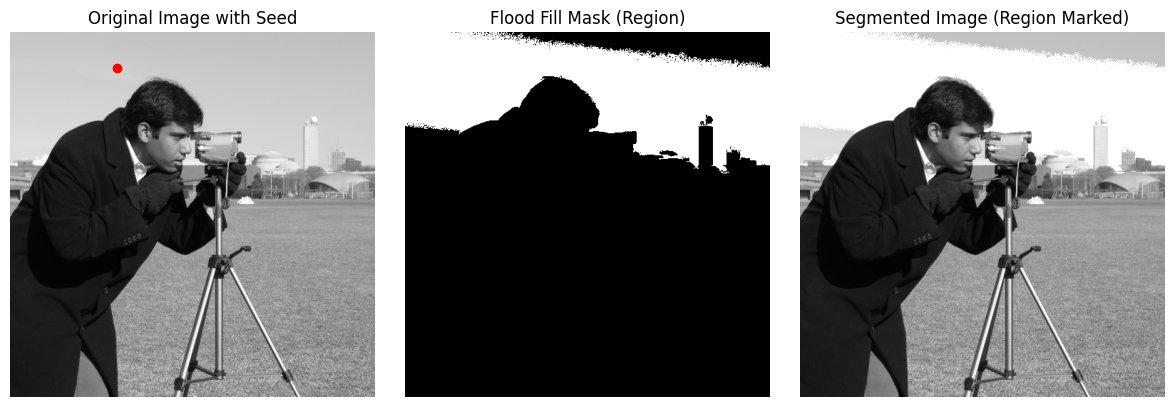

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misalnya, titik di area langit: koordinat (y=50, x=150)
seed_point = (50, 150)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=10)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai titik seed
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()


#
Amati region yang dihasilkan oleh algoritma flood. Bagaimana pengaruh parameter tolerance terhadap ukuran region yang 'tumbuh'? Cobalah mengubah titik seed dan nilai tolerance.

Jawab:

Semakin besar nilai tolerance, semakin luas region yang tumbuh karena piksel dengan intensitas lebih bervariasi akan disertakan. Sebaliknya, nilai tolerance kecil membuat region tumbuh terbatas hanya pada piksel yang sangat mirip dengan titik seed.

#Mencoba mengubah titik seed dan nilai tolerance. Menjadi seed_point = (100, 200) dan tolerance=20

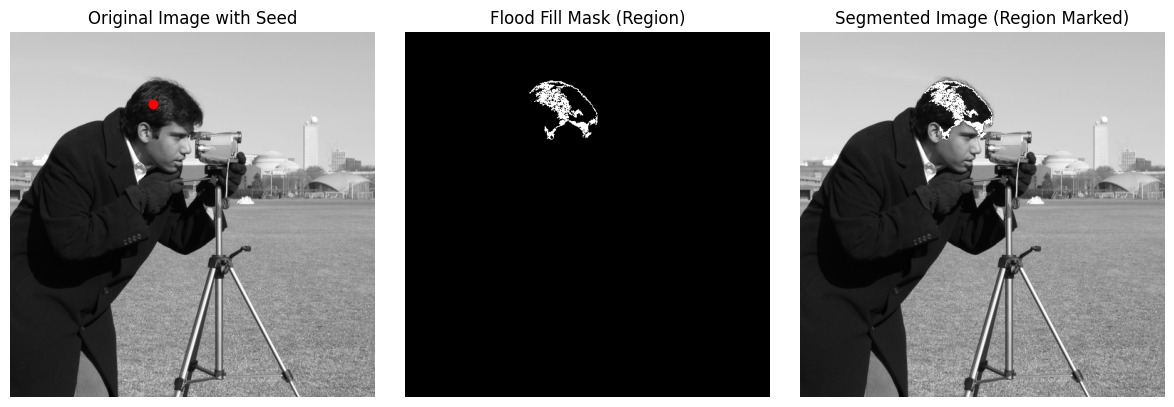

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, segmentation, color

# 1. Memuat citra (contoh: camera)
image_camera = data.camera()

# 2. Tentukan titik 'seed' (benih)
# Misalnya, titik di area langit: koordinat (y=50, x=150)
seed_point = (100, 200)

# 3. Terapkan algoritma flood fill (mirip region growing)
# 'tolerance' menentukan seberapa besar perbedaan intensitas yang diizinkan
flood_mask = segmentation.flood(image_camera, seed_point, tolerance=20)

# 4. Buat citra tersegmentasi (tandai region yang 'tumbuh')
segmented_image = np.copy(image_camera)
segmented_image[flood_mask] = 255  # Tandai region dengan warna putih

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_camera, cmap='gray')
ax[0].plot(seed_point[1], seed_point[0], 'ro')  # Tandai titik seed
ax[0].set_title('Original Image with Seed')
ax[0].axis('off')

ax[1].imshow(flood_mask, cmap='gray')
ax[1].set_title('Flood Fill Mask (Region)')
ax[1].axis('off')

ax[2].imshow(segmented_image, cmap='gray')
ax[2].set_title('Segmented Image (Region Marked)')
ax[2].axis('off')

plt.tight_layout()
plt.show()

#Praktikum 3. Segmentasi Citra Berwarna Menggunakan K-Means Clustering

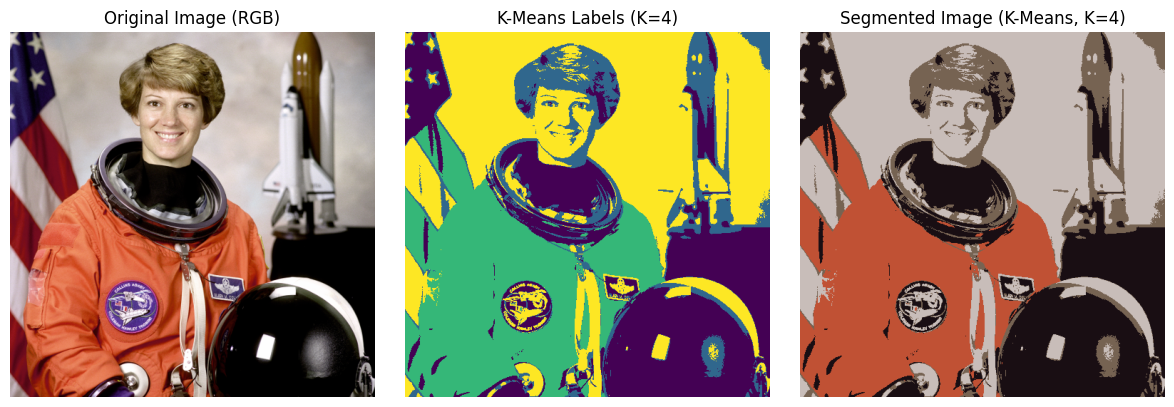

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()

# Konversi ke float [0, 1] untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Konversi ke ruang warna Lab (lebih sesuai persepsi manusia)
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape

# Ubah ke bentuk [jumlah_piksel, jumlah_fitur]
pixel_features = image_lab.reshape(rows * cols, dims)

# 3. Terapkan K-Means Clustering
n_clusters = 4
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Sembunyikan warning dari sklearn
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Kembalikan label hasil klaster ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Bangun citra baru berdasarkan warna pusat klaster
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask_k = (pixel_labels == k).reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()


#
Amati hasil segmentasi K-Means. Apakah jumlah klaster (K) mempengaruhi hasil segmentasi secara signifikan? Iya, jumlah klaster (K) sangat mempengaruhi hasil segmentasi. Semakin kecil K, segmentasi lebih kasar dengan sedikit warna; semakin besar K, detail meningkat tetapi bisa menyebabkan fragmentasi warna. Pemilihan K yang tepat penting untuk keseimbangan antara detail dan kesederhanaan.

#mengubah nilai K

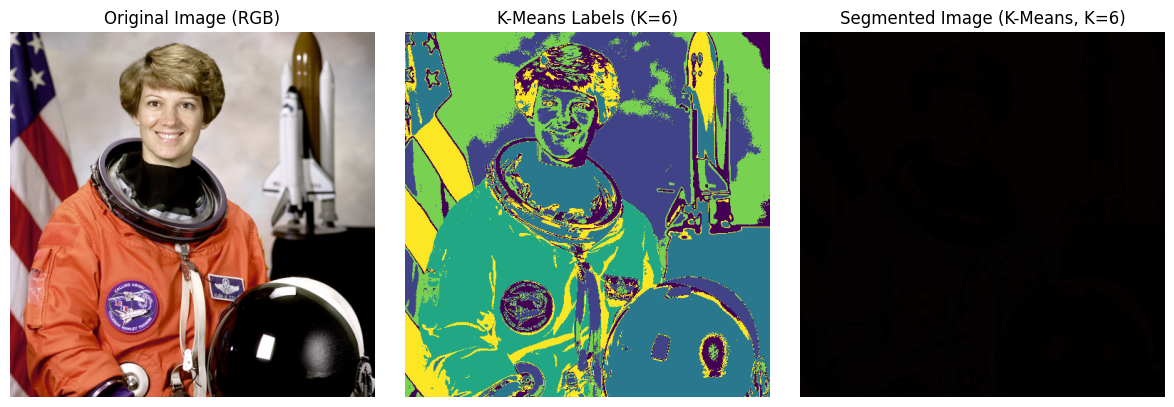

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data
from sklearn.cluster import KMeans
from skimage.color import rgb2lab, lab2rgb
import warnings

# 1. Memuat citra berwarna (contoh: astronaut)
image_astro = data.astronaut()

# Konversi ke float [0, 1] untuk perhitungan
image_astro_float = image_astro.astype(float) / 255.0

# 2. Konversi ke ruang warna Lab (lebih sesuai persepsi manusia)
image_lab = rgb2lab(image_astro_float)
rows, cols, dims = image_lab.shape

# Ubah ke bentuk [jumlah_piksel, jumlah_fitur]
pixel_features = image_astro_float.reshape(-1, 3)


# 3. Terapkan K-Means Clustering
n_clusters = 6
kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)

# Sembunyikan warning dari sklearn
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

# 4. Kembalikan label hasil klaster ke bentuk citra
segmented_labels = pixel_labels.reshape(rows, cols)

# 5. Bangun citra baru berdasarkan warna pusat klaster
segmented_image_kmeans = np.zeros_like(image_lab)
centers_lab = kmeans.cluster_centers_

for k in range(n_clusters):
    mask_k = (pixel_labels == k).reshape(rows, cols)
    segmented_image_kmeans[mask_k] = centers_lab[k]

# Konversi kembali ke RGB untuk ditampilkan
segmented_image_rgb = lab2rgb(segmented_image_kmeans)

# 6. Visualisasi hasil
fig, axes = plt.subplots(ncols=3, figsize=(12, 4))
ax = axes.ravel()

ax[0].imshow(image_astro)
ax[0].set_title('Original Image (RGB)')
ax[0].axis('off')

ax[1].imshow(segmented_labels, cmap='viridis')
ax[1].set_title(f'K-Means Labels (K={n_clusters})')
ax[1].axis('off')

ax[2].imshow(segmented_image_rgb)
ax[2].set_title(f'Segmented Image (K-Means, K={n_clusters})')
ax[2].axis('off')

plt.tight_layout()
plt.show()


#Praktikum 4. Segmentasi Berbasis Tepi Menggunakan Watershed

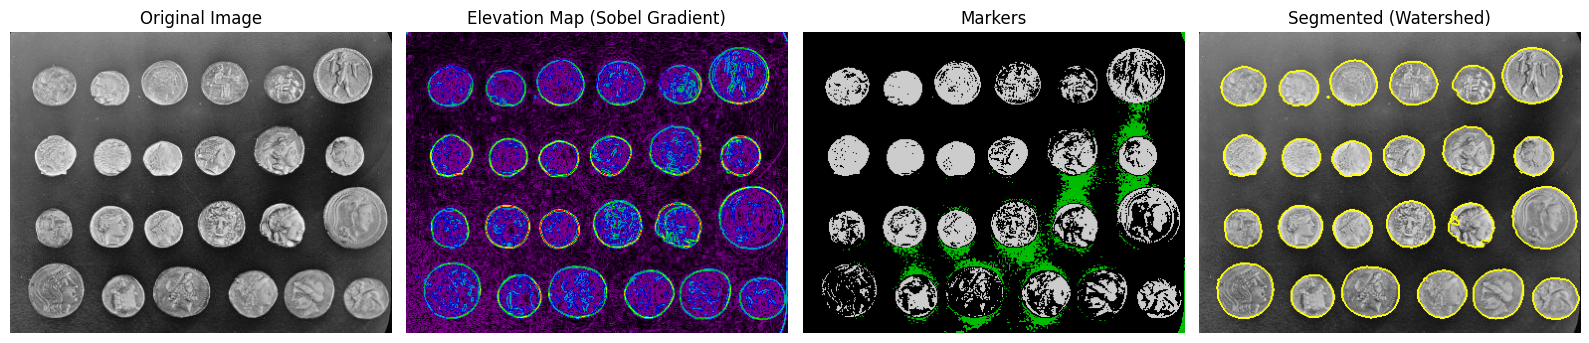

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, morphology, measure
from scipy import ndimage as ndi

# 1. Memuat citra (contoh: coins)
image_coins = data.coins()

# 2. Hitung gradien citra (sebagai 'topografi')
elevation_map = filters.sobel(image_coins)

# 3. Tentukan marker (penanda awal untuk setiap cekungan/objek)
markers = np.zeros_like(image_coins)
markers[image_coins < 30] = 1   # Marker untuk latar belakang
markers[image_coins > 150] = 2  # Marker untuk objek (koin)

# (Alternatif canggih - menggunakan local maxima)
# from skimage.feature import peak_local_max
# image_max = ndi.maximum_filter(image_coins, size=20, mode='constant')
# coordinates = peak_local_max(image_coins, min_distance=20)
# markers = np.zeros(image_coins.shape, dtype=bool)
# markers[tuple(coordinates.T)] = True
# markers = measure.label(markers)

# 4. Terapkan algoritma Watershed
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# Warnai hasil segmentasi untuk visualisasi
segmented_colored = segmentation.mark_boundaries(image_coins, segmentation_watershed)

# 5. Visualisasi Hasil
fig, axes = plt.subplots(ncols=4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image_coins, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(elevation_map, cmap=plt.cm.nipy_spectral)
ax[1].set_title('Elevation Map (Sobel Gradient)')
ax[1].axis('off')

ax[2].imshow(markers, cmap=plt.cm.nipy_spectral)
ax[2].set_title('Markers')
ax[2].axis('off')

ax[3].imshow(segmented_colored)
ax[3].set_title('Segmented (Watershed)')
ax[3].axis('off')

plt.tight_layout()
plt.show()


#
Amati bagaimana algoritma Watershed menggunakan gradien dan marker untuk memisahkan objek. Bagaimana pemilihan marker mempengaruhi hasil akhir? Apa yang terjadi jika marker tidak tepat?

Algoritma Watershed menggunakan gradien sebagai topografi dan marker sebagai titik awal "banjir". Pemilihan marker sangat mempengaruhi hasil; marker yang tepat menghasilkan pemisahan objek yang akurat. Jika marker salah atau tidak representatif, hasilnya bisa over-segmented (terlalu banyak area) atau under-segmented (objek tidak terpisah dengan jelas).










#Praktikum 5. Perbandingan Visual Hasil Segmentasi

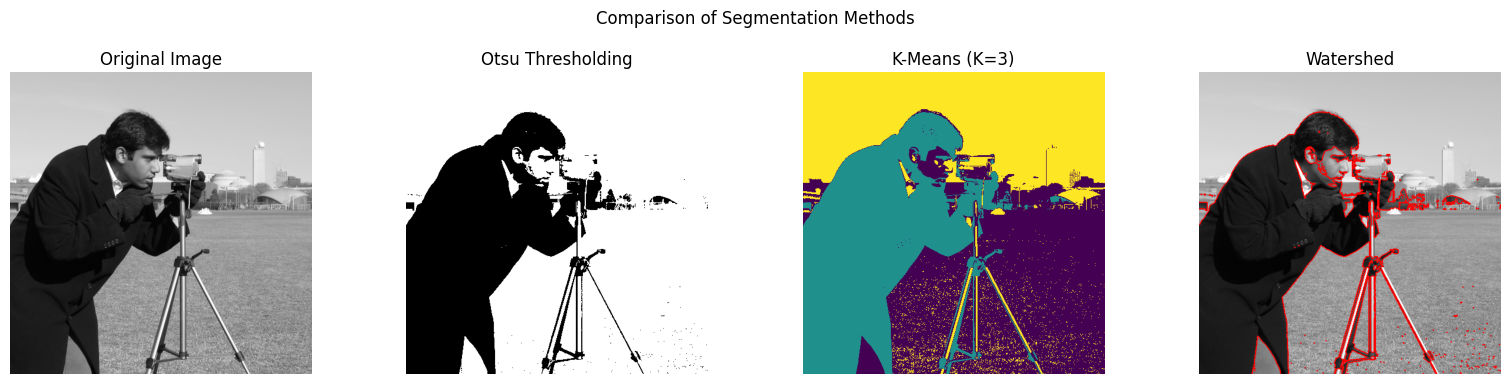

In [ ]:
import matplotlib.pyplot as plt
from skimage import data, filters, segmentation, img_as_float, color
from sklearn.cluster import KMeans
import numpy as np
import warnings

# 1. Pilih satu citra untuk perbandingan (misal: camera)
image = data.camera()
image_float = img_as_float(image)

# 2. Lakukan beberapa metode segmentasi

# a) Otsu Thresholding
thresh_otsu = filters.threshold_otsu(image)
binary_otsu = image > thresh_otsu

# b) K-Means (misal K=3)
rows, cols = image.shape
pixel_features = image_float.reshape(rows * cols, 1)
n_clusters = 3

kmeans = KMeans(n_clusters=n_clusters, random_state=0, n_init=10)
with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    pixel_labels = kmeans.fit_predict(pixel_features)

segmented_kmeans_labels = pixel_labels.reshape(rows, cols)

# c) Watershed (gunakan marker sederhana dari Otsu)
elevation_map = filters.sobel(image)
markers = np.zeros_like(image)
markers[image < thresh_otsu] = 1
markers[image > thresh_otsu] = 2
segmentation_watershed = segmentation.watershed(elevation_map, markers)

# 3. Visualisasi Perbandingan
fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].set_title('Original Image')
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap=plt.cm.gray)
ax[1].set_title('Otsu Thresholding')
ax[1].axis('off')

ax[2].imshow(segmented_kmeans_labels, cmap='viridis')
ax[2].set_title(f'K-Means (K={n_clusters})')
ax[2].axis('off')

segmented_watershed_colored = segmentation.mark_boundaries(image_float, segmentation_watershed, color=(1, 0, 0))
ax[3].imshow(segmented_watershed_colored)
ax[3].set_title('Watershed')
ax[3].axis('off')

plt.suptitle('Comparison of Segmentation Methods')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


#
Bandingkan hasil ketiga metode pada citra yang sama. Metode mana yang paling baik dalam memisahkan objek utama? Metode mana yang menghasilkan region paling halus atau paling detail? Apa kelebihan dan kekurangan masing-masing metode berdasarkan hasil visual ini?

Otsu cepat dan sederhana, baik untuk pemisahan kontras tinggi, tapi gagal jika pencahayaan tidak merata.
K-Means memberikan segmentasi lebih detail dan fleksibel, tapi rentan terhadap noise dan butuh pemilihan K yang tepat.
Watershed paling baik dalam memisahkan objek utama dengan batas jelas, tapi bisa over-segmentasi jika marker tidak akurat.

Kesimpulan:

Terbaik memisahkan objek: Watershed

Region paling halus/detail: K-Means

Paling cepat dan sederhana: Otsu

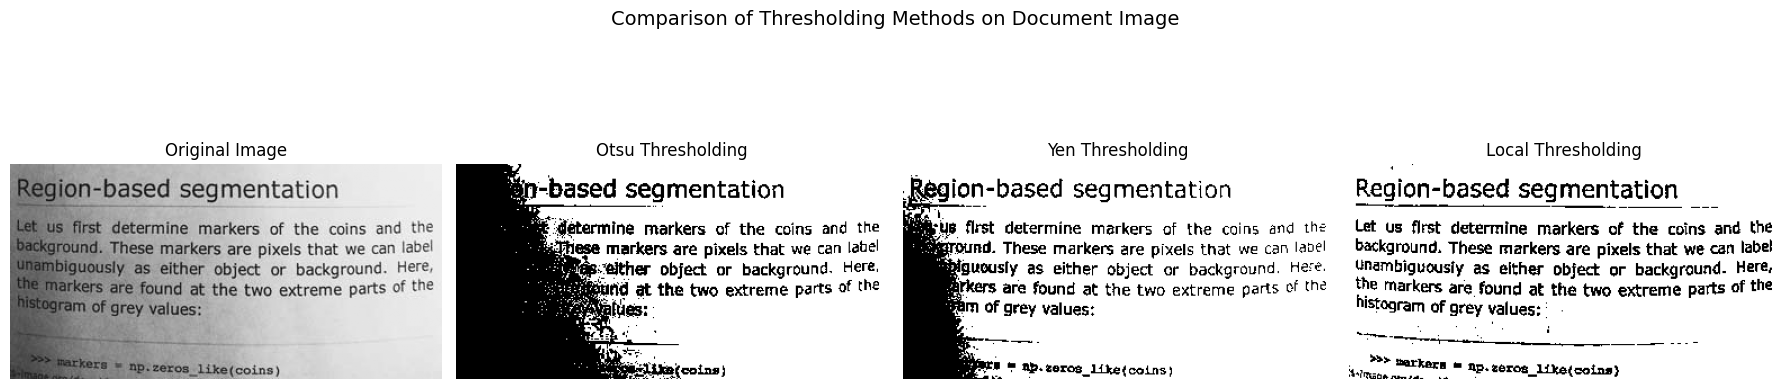

In [13]:
import matplotlib.pyplot as plt
from skimage import data, filters
from skimage.filters import threshold_otsu, threshold_yen, threshold_local
from skimage import img_as_float
import numpy as np

# 1. Load citra dokumen
image = data.page()
image_float = img_as_float(image)

# 2. Thresholding Otsu
thresh_otsu = threshold_otsu(image)
binary_otsu = image > thresh_otsu

# 3. Thresholding Yen
thresh_yen = threshold_yen(image)
binary_yen = image > thresh_yen

# 4. Thresholding Lokal (Adaptif)
block_size = 35  # Ukuran jendela lokal
thresh_local = threshold_local(image, block_size, offset=10)
binary_local = image > thresh_local

# 5. Visualisasi
fig, axes = plt.subplots(1, 4, figsize=(18, 5), sharex=True, sharey=True)
ax = axes.ravel()

ax[0].imshow(image, cmap='gray')
ax[0].set_title("Original Image")
ax[0].axis('off')

ax[1].imshow(binary_otsu, cmap='gray')
ax[1].set_title("Otsu Thresholding")
ax[1].axis('off')

ax[2].imshow(binary_yen, cmap='gray')
ax[2].set_title("Yen Thresholding")
ax[2].axis('off')

ax[3].imshow(binary_local, cmap='gray')
ax[3].set_title("Local Thresholding")
ax[3].axis('off')

plt.suptitle("Comparison of Thresholding Methods on Document Image", fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()


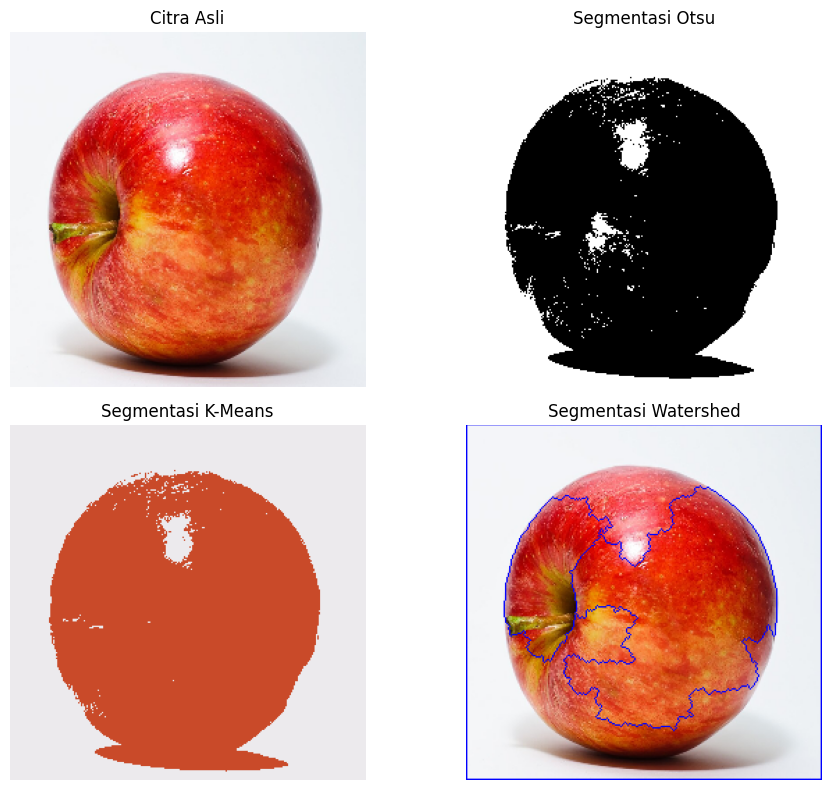

In [17]:
# Instalasi pustaka jika belum tersedia
!pip install -q opencv-python-headless matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from urllib.request import urlopen
from skimage.segmentation import watershed
from skimage.feature import peak_local_max
from scipy import ndimage as ndi

# Fungsi untuk menampilkan citra
def show_images(titles, images, cols=2):
    rows = (len(images) + cols - 1) // cols
    plt.figure(figsize=(5 * cols, 4 * rows))
    for i in range(len(images)):
        plt.subplot(rows, cols, i + 1)
        if len(images[i].shape) == 2:
            plt.imshow(images[i], cmap='gray')
        else:
            plt.imshow(cv2.cvtColor(images[i], cv2.COLOR_BGR2RGB))
        plt.title(titles[i])
        plt.axis('off')
    plt.tight_layout()
    plt.show()

# Unduh citra buah dari internet
url = "https://upload.wikimedia.org/wikipedia/commons/thumb/1/15/Red_Apple.jpg/800px-Red_Apple.jpg"
resp = urlopen(url)
image_array = np.asarray(bytearray(resp.read()), dtype=np.uint8)
image = cv2.imdecode(image_array, cv2.IMREAD_COLOR)
image = cv2.resize(image, (256, 256))

# Konversi ke grayscale untuk metode tertentu
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

### --- 1. Segmentasi Otsu --- ###
_, otsu_mask = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

### --- 2. Segmentasi K-Means --- ###
Z = image.reshape((-1, 3))
Z = np.float32(Z)

criteria = (cv2.TERM_CRITERIA_EPS + cv2.TERM_CRITERIA_MAX_ITER, 10, 1.0)
K = 2  # Jumlah cluster
_, labels, centers = cv2.kmeans(Z, K, None, criteria, 10, cv2.KMEANS_RANDOM_CENTERS)
centers = np.uint8(centers)
segmented_data = centers[labels.flatten()]
kmeans_result = segmented_data.reshape((image.shape))

### --- 3. Segmentasi Watershed --- ###
# Threshold awal
_, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# Noise removal
kernel = np.ones((3,3), np.uint8)
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=2)
# Area background
sure_bg = cv2.dilate(opening, kernel, iterations=3)
# Area foreground
dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist_transform, 0.7*dist_transform.max(), 255, 0)
# Marker labelling
sure_fg = np.uint8(sure_fg)
unknown = cv2.subtract(sure_bg, sure_fg)
_, markers = cv2.connectedComponents(sure_fg)
markers = markers + 1
markers[unknown==255] = 0
# Terapkan watershed
watershed_image = image.copy()
markers = cv2.watershed(watershed_image, markers)
watershed_image[markers == -1] = [255, 0, 0]  # Garis batas = merah

### --- Tampilkan semua hasil --- ###
show_images(
    ["Citra Asli", "Segmentasi Otsu", "Segmentasi K-Means", "Segmentasi Watershed"],
    [image, otsu_mask, kmeans_result, watershed_image]
)
